In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db_path = 'database/analytics.duckdb'
pd.set_option('display.max_colwidth', 45)

with duckdb.connect(db_path) as conn:
    types = conn.execute("""
    SELECT 
        contract_type,
        EXTRACT(YEAR FROM placement_date) AS year,
        SUM(total_price) / 1000000 AS total_sum_mln, 
        COUNT(*) AS amount
    FROM order_cards
    WHERE placement_date IS NOT NULL
    GROUP BY contract_type, year
    ORDER BY year, total_sum_mln;
""").fetchdf()
    print('= = = типы заявок = = =')
    types['total_sum_mln'] = types['total_sum_mln'].round(2)
    print(types)

    statuses = conn.execute("""
        SELECT DISTINCT status FROM order_cards
    """).fetchdf()
    print('\n= = = статусы заявок = = =')
    print(statuses)

= = = типы заявок = = =
                                   contract_type  year  total_sum_mln  amount
0   44-ФЗ Электронный аукцион для заключения ...  2023           0.35       1
1   44-ФЗ Запрос котировок в электронной форм...  2023           4.56       1
2   44-ФЗ Открытый конкурс в электронной форм...  2023          21.53       2
3   44-ФЗ Открытый конкурс в электронной форм...  2023        1103.94     110
4   44-ФЗ Закупка, осуществляемая в соответст...  2023        1487.52    2103
5   44-ФЗ Открытый конкурс в электронной форм...  2023        1716.91     121
6   44-ФЗ Электронный аукцион для торгов по о...  2023        1758.99       4
7   44-ФЗ Электронный аукцион на проведение р...  2023       34889.81     366
8     44-ФЗ Запрос котировок в электронной форме  2023       37245.59   27170
9     44-ФЗ Открытый конкурс в электронной форме  2023      231413.15    9094
10  44-ФЗ Открытый конкурс в электронной форм...  2023      237722.59     724
11                     44-ФЗ Электронный

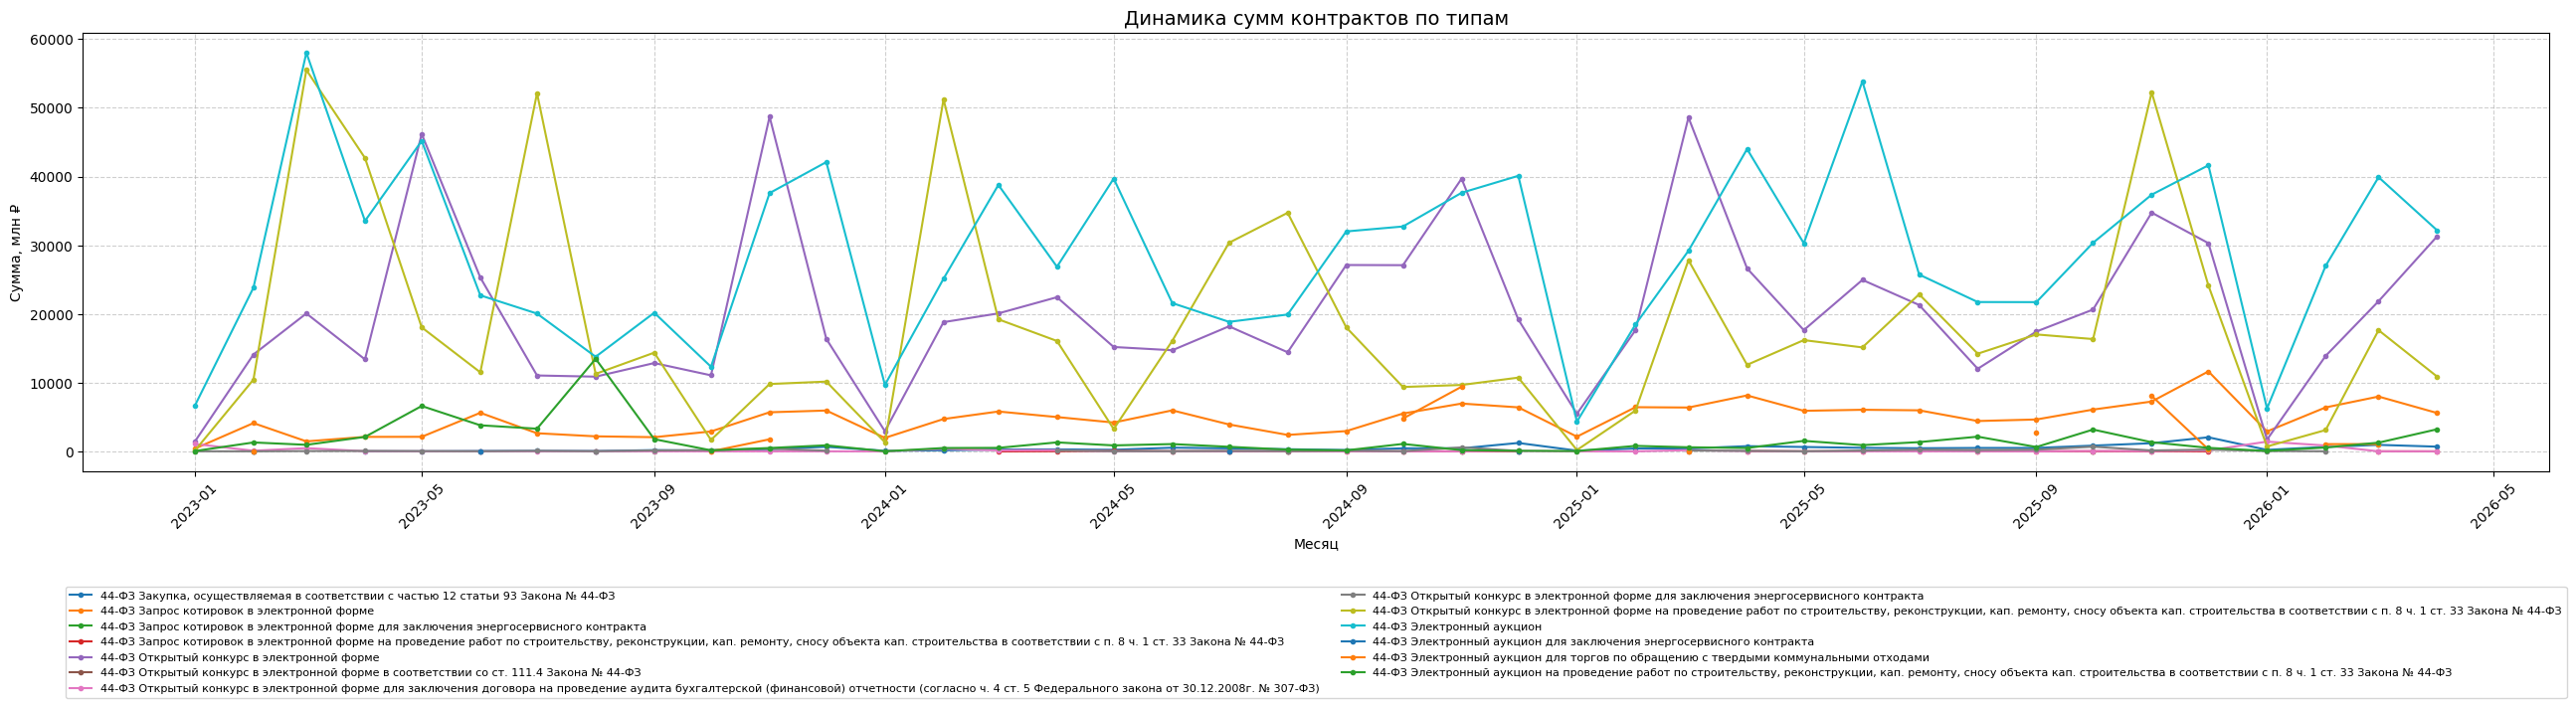

In [2]:
with duckdb.connect(db_path) as conn:
    df = conn.execute("""
        SELECT
            contract_type,
            DATE_TRUNC('month', placement_date) AS month,
            SUM(total_price) / 1000000.0 AS total_mln
        FROM order_cards
        WHERE placement_date IS NOT NULL
        GROUP BY contract_type, month
        ORDER BY month, contract_type;
    """).fetchdf()

# Преобразуем month в datetime pandas
df['month'] = pd.to_datetime(df['month'])

# Создаём сводную таблицу: строки – месяцы, столбцы – contract_type, значения – total_mln
pivot = df.pivot(index='month', columns='contract_type', values='total_mln')

# Построение графика
plt.figure(figsize=(32, 7))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col, marker='.', linewidth=1.5)

plt.title('Динамика сумм контрактов по типам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Сумма, млн ₽')
plt.subplots_adjust(bottom=0.25)  # освободить место снизу
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=8)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

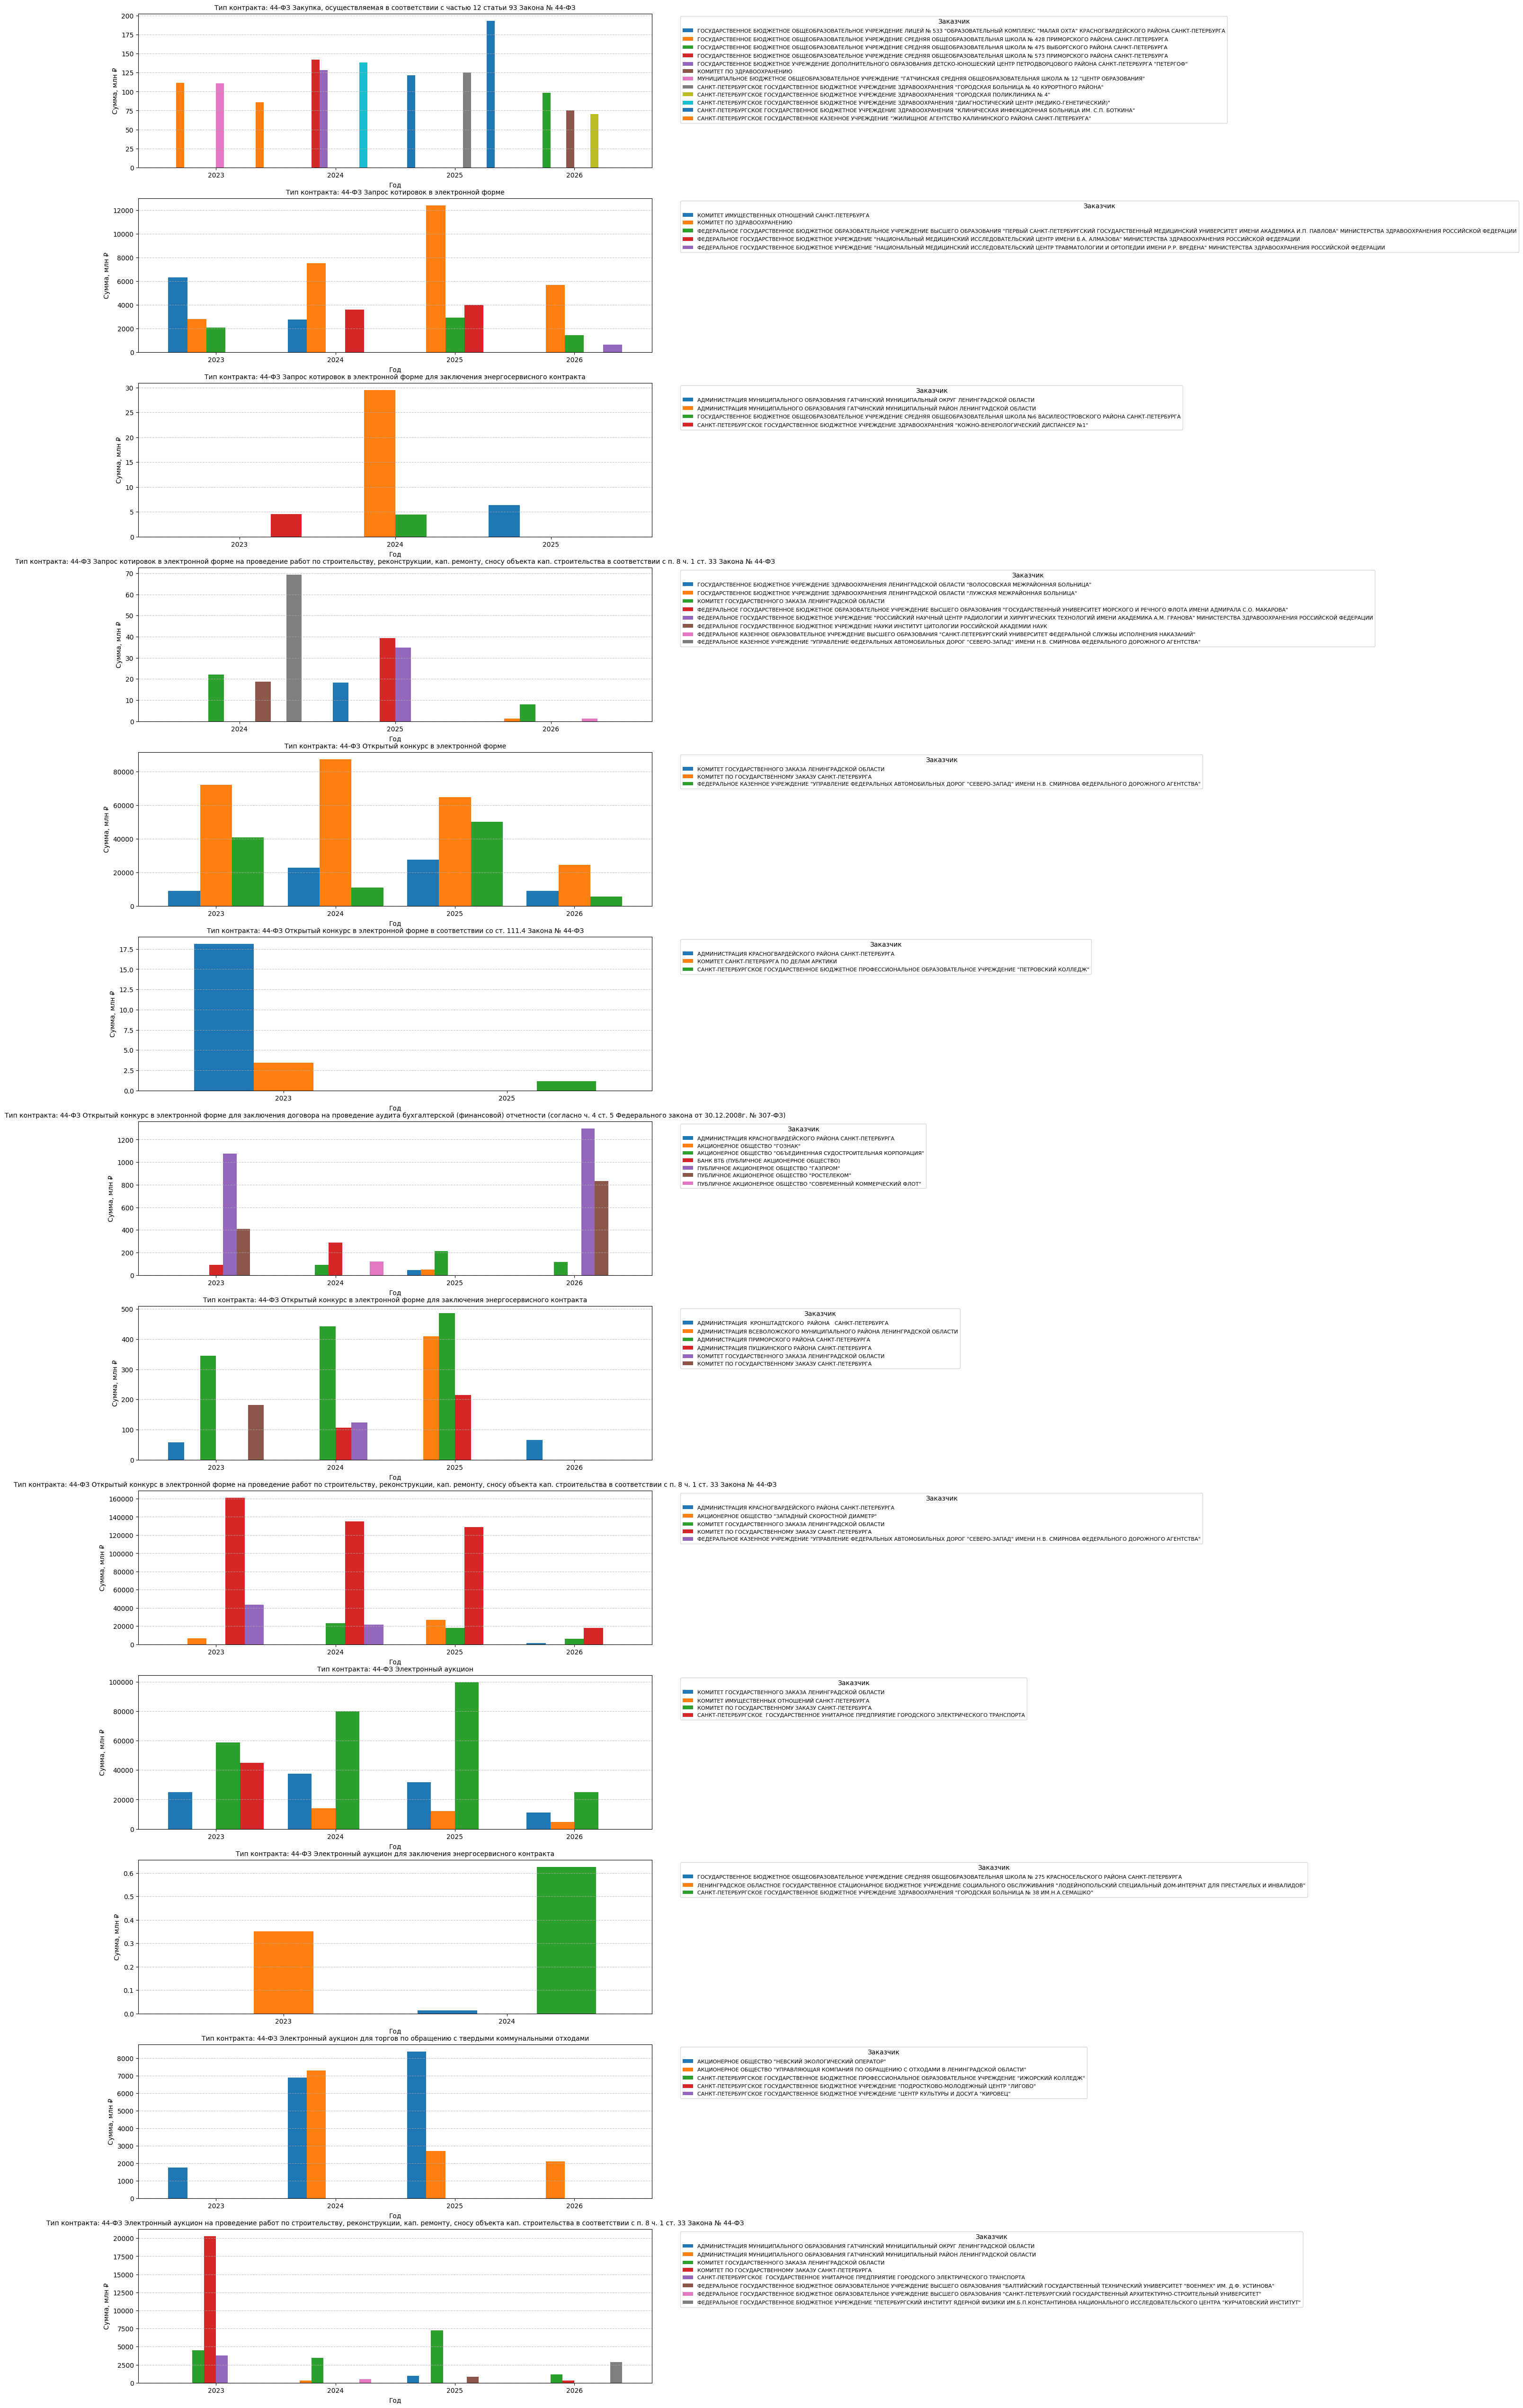

In [7]:
# топ 3 заказчиков по каждому типу contract_type, за год
with duckdb.connect(db_path) as conn:
    df = conn.execute("""
        WITH ranked AS (
            SELECT
                EXTRACT(YEAR FROM oc.placement_date) AS year,
                oc.contract_type,
                c.name AS consumer_name,
                SUM(oc.total_price) AS total,
                ROW_NUMBER() OVER (
                    PARTITION BY oc.contract_type, EXTRACT(YEAR FROM oc.placement_date)::INTEGER
                    ORDER BY SUM(oc.total_price) DESC
                ) AS rn
            FROM order_cards oc
            JOIN consumers c ON oc.consumer_id = c.id
            WHERE oc.placement_date IS NOT NULL
            GROUP BY year, oc.contract_type, c.name
        )
        SELECT
            year,
            contract_type,
            consumer_name,
            total / 1000000.0 AS total_mln
        FROM ranked
        WHERE rn <= 3
        ORDER BY contract_type, year, total_mln DESC;
    """).fetchdf()

# Преобразуем year в целое число
df['year'] = df['year'].astype(int)

# Построение графиков: отдельный подграфик для каждого contract_type
contract_types = df['contract_type'].unique()
n_types = len(contract_types)
cols = 1  # количество столбцов в сетке подграфиков
rows = (n_types + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), squeeze=False)
axes = axes.flatten()

for idx, ct in enumerate(contract_types):
    ax = axes[idx]
    subset = df[df['contract_type'] == ct].copy()
    # Сортируем по году, чтобы столбцы были в правильном порядке
    years = sorted(subset['year'].unique())
    # Для каждого года и заказчика нужно подготовить данные
    # Используем pivot: строки – year, столбцы – consumer_name, значения – total_mln
    pivot = subset.pivot(index='year', columns='consumer_name', values='total_mln')
    pivot = pivot.reindex(years)  # убеждаемся, что годы идут по порядку
    # Рисуем столбчатую диаграмму с группировкой
    pivot.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'Тип контракта: {ct}', fontsize=10)
    ax.set_xlabel('Год')
    ax.set_ylabel('Сумма, млн ₽')
    ax.legend(title='Заказчик', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    # Поворачиваем подписи лет, если нужно
    ax.tick_params(axis='x', rotation=0)

# Скрыть неиспользуемые подграфики
for idx in range(len(contract_types), len(axes)):
    fig.delaxes(axes[idx])

# plt.tight_layout()
plt.show()